# ML Module 1 — Traditional Machine Learning
## Hands-on Notebook: from Correlation to Regularized Regression

**Story of this notebook** (same as the live session):

`Data → Correlation → Simple Linear Regression → Gradient Descent → Multiple Linear Regression → Evaluation → Overfitting → Ridge & Lasso → Compare`

### How to use this notebook
| Symbol | Meaning |
|---|---|
| ▶️ | **Run it** — worked example, just read and run |
| ✏️ | **Your turn** — fill in the `...` / `None` parts, then run the ✔️ check cell below it |
| ✔️ | **Check** — prints ✅ if your answer is right, ❌ plus a hint if not |
| 🏆 | **Challenge** — bigger, more open tasks |
| 📝 | **Assignment** — a full mini-project on a new dataset |

Run cells **top to bottom** (`Shift + Enter`). If something breaks, use *Kernel → Restart & Run All*.

*Example data is set in London: prices in **£ thousands**, area in **sq ft**, distance in **miles from central London**.*

## 0 · Setup ▶️

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.precision", 3)
plt.rcParams["figure.figsize"] = (7, 4)

def check(label, test, hint=""):
    """Self-check helper: prints ✅ or ❌ (with a hint)."""
    try:
        ok = bool(test())
    except Exception as e:
        ok, hint = False, f"{hint}  (error: {type(e).__name__}: {e})"
    print(("✅ " if ok else "❌ ") + label + ("" if ok else f"\n   hint: {hint}"))

print("Ready!")

Ready!


## 1 · The dataset ▶️
500 London homes. We generate the data with a fixed random seed so **everyone gets identical numbers**.
We also add `random_noise` — a column with **no** relationship to price. Keep an eye on it.

# TMB practice
n=500
np.random.normal(loc=0.0, scale=1.0, size=None) #loc:mean, scale:std dev, size;output array shape
np.random.normal(loc=10, scale=3, size=(3,4))

np.clip(np.round(area / 350 + rng.normal(0, 0.7, 500)), 1, 6)
rng.uniform(0, 100, 20).round()  # uniform distr random.uniform(low, high, size)


In [2]:
rng = np.random.default_rng(42)  # seed of 42
n = 500

area = rng.normal(900, 300, n).clip(300, 2500).round()              # sq ft .normal gauss distr; .clip top & bottom limit
bedrooms = np.clip(np.round(area / 350 + rng.normal(0, 0.7, n)), 1, 6)
age = rng.uniform(0, 120, n).round()                                # years
distance = rng.uniform(1, 20, n).round(1)                           # miles from central London
random_noise = rng.normal(0, 1, n).round(2)                         # a useless feature

price = (300 + 0.45 * area + 25 * bedrooms - 0.8 * age
         - 18 * distance + rng.normal(0, 45, n))                    # £ thousands

df = pd.DataFrame({
    "area": area, "bedrooms": bedrooms, "age": age,
    "distance": distance, "random_noise": random_noise,
    "price": price.clip(150).round()
})
print(df.shape)
df.head()

(500, 6)


,area,bedrooms,age,distance,random_noise,price
0,991.0,4.0,78.0,10.1,0.39,638.0
1,588.0,2.0,41.0,15.9,0.55,264.0
2,1125.0,3.0,49.0,15.2,0.23,603.0
3,1182.0,2.0,53.0,16.5,0.97,508.0
4,315.0,1.0,15.0,9.5,0.09,333.0


In [3]:
df.describe()

,area,bedrooms,age,distance,random_noise,price
count,500.000,500.000,500.000,500.000,500.000,500.000
mean,897.246,2.582,59.898,10.644,0.005,532.980
std,285.285,1.068,35.047,5.461,1.012,191.048
min,300.000,1.000,0.000,1.000,-3.060,150.000
25%,699.750,2.000,27.000,5.775,-0.663,400.750
50%,901.000,3.000,58.000,10.400,0.045,539.500
75%,1076.250,3.000,91.000,15.500,0.630,661.000
max,1774.000,6.000,120.000,20.000,2.860,1202.000


**Read the output:** the average home costs about **£533k**; areas range from 300 to ~1,800 sq ft.

## 2 · Understand relationships first: correlation ▶️
Before modelling, look at how each feature moves with `price`.

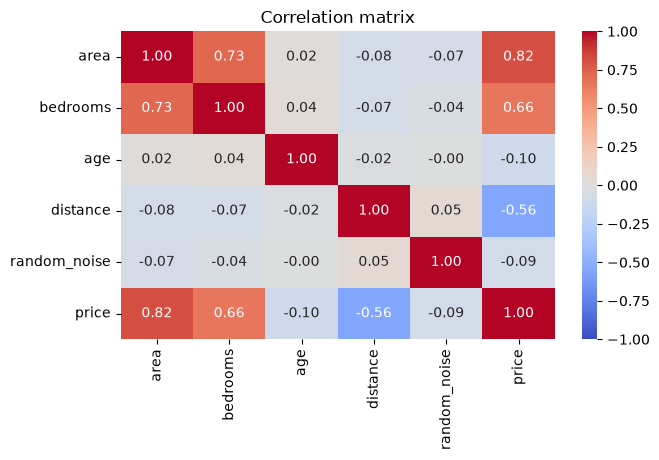

price           1.000
area            0.820
bedrooms        0.662
random_noise   -0.086
age            -0.103
distance       -0.560
Name: price, dtype: float64

In [4]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()

corr["price"].sort_values(ascending=False)

### ✏️ Exercise 1 — read the correlation table with code
Store in `most_negative` the **name** of the feature (not `price`) with the **most negative** correlation with price.
*Tip:* `Series.drop(...)` and `Series.idxmin()`.

In [5]:
# ✏️ YOUR TURN — replace the ... / None parts
most_negative = corr["distance"]   # e.g. corr["price"]...
print(most_negative)

area           -0.077
bedrooms       -0.073
age            -0.023
distance        1.000
random_noise    0.049
price          -0.560
Name: distance, dtype: float64


In [6]:
# ✔️ CHECK
check("Exercise 1", lambda: most_negative == df.corr(numeric_only=True)["price"].drop("price").idxmin(),
      "drop 'price' from corr['price'], then use .idxmin()")

❌ Exercise 1
   hint: drop 'price' from corr['price'], then use .idxmin()  (error: ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().)


> 💬 **Think:** `area` and `bedrooms` are strongly correlated with *each other* (~0.73). What problem might that cause when we use both as features?

## 3 · Simple Linear Regression ▶️
One feature (`area`) → one target (`price`).

In [7]:
# np.reshape(rows, columns) #flattening an array with -1; can only be in one dimension 
# The -1 means that dimension is whatever size is needed to let the given array fit the other dimensions. 
# When the other dimension is 1, the -1 is the same as the length. 
# So these are equivalent:
# arr.reshape(-1, 1)
# arr.reshape(len(arr), 1)
# If the other dimension is 2, then obviously the first one needs to be the length divided by 2. 
# So these are equivalent:
# arr.reshape(-1, 2)
# arr.reshape(len(arr)//2, 2)
# Etc. You see -1 just tells numpy to figure out the math to make it fit, so you don't have to.

# np.linspace(300, 1800, 50).reshape(-1, 1)

slope (coef_)      = 0.543  → each extra sq ft adds about £543
intercept_         = 43.7


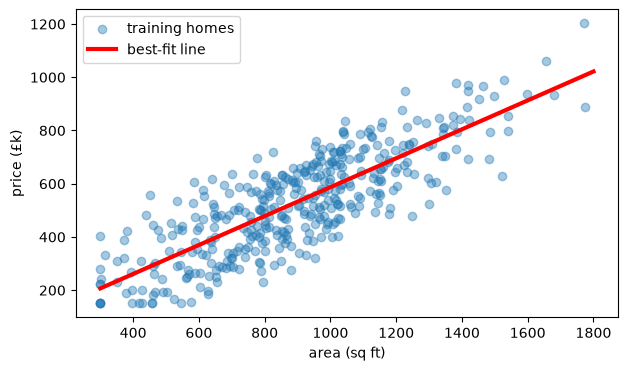

In [8]:
X_simple = df[["area"]]          # double brackets → a 2-D table
y = df["price"]

Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

simple = LinearRegression()
simple.fit(Xs_train, ys_train)

print(f"slope (coef_)      = {simple.coef_[0]:.3f}  → each extra sq ft adds about £{simple.coef_[0]*1000:,.0f}")
print(f"intercept_         = {simple.intercept_:.1f}")

plt.scatter(Xs_train, ys_train, alpha=0.4, label="training homes")
xx = np.linspace(300, 1800, 50).reshape(-1, 1)
plt.plot(xx, simple.predict(pd.DataFrame(xx, columns=["area"])), "r", lw=3, label="best-fit line")
plt.xlabel("area (sq ft)"); plt.ylabel("price (£k)"); plt.legend(); plt.show()

### ✏️ Exercise 2 — make a prediction
Use the trained `simple` model to predict the price of a **1,200 sq ft** home. Store the number (in £k) in `pred_1200`.
*Tip:* `predict` expects a table with the same column name: `pd.DataFrame({"area": [1200]})`.

In [9]:
# ✏️ YOUR TURN — replace the ... / None parts
twelve_hundred = pd.DataFrame({"area":[1200]})
pred_1200 = simple.predict(twelve_hundred)
print(pred_1200)

[695.6896535]


In [10]:
# ✔️ CHECK
check("Exercise 2", lambda: abs(pred_1200 - (simple.intercept_ + simple.coef_[0] * 1200)) < 1e-6,
      "simple.predict(pd.DataFrame({'area': [1200]}))[0]")

✅ Exercise 2


## 4 · Under the hood: Gradient Descent ▶️✏️
How does a model *find* the best line? It starts with any line and repeatedly steps "downhill" on the error.

| Step | Formula |
|---|---|
| Predict | `y_pred = m*x + c` |
| Error | `error = y_pred - y` |
| Cost | `MSE = mean(error²)` |
| Gradients | `dm = (2/n)·Σ(error·x)`,  `dc = (2/n)·Σ error` |
| Update | `m = m - lr·dm`,  `c = c - lr·dc` |

Tiny example: 3 flats — 400, 600, 800 sq ft → £300k, £400k, £500k (area in 100s of sq ft, price in £100k).

### ✏️ Exercise 3 — write the update step
Complete the two `...` lines so the function performs gradient descent and returns the final MSE.

In [11]:
# ✏️ YOUR TURN — replace the ... / None parts
x = np.array([4, 6, 8])
y_small = np.array([3, 4, 5])
alpha = 0.01

def run_gd(lr, steps=100):
    m, c = 0.0, 0.0
    n_pts = len(x)
    for _ in range(steps):
        error = (m * x + c) - y_small
        dm = (2 / n_pts) * (error * x).sum()
        dc = (2 / n_pts) * error.sum()
        m = m - (alpha * dm)      # step downhill for m
        c = c - (alpha * dc)     # step downhill for c
    return ((m * x + c - y_small) ** 2).mean(), m, c

print(run_gd(0.01))

(np.float64(0.042714333378310654), np.float64(0.6223301280687771), np.float64(0.21302326234330066))


In [12]:
# ✔️ CHECK
check("Exercise 3", lambda: run_gd(0.01)[0] < 0.05, "m = m - lr * dm  and  c = c - lr * dc")

# ▶️ Now compare learning rates
for lr in [0.002, 0.01, 0.025, 0.03]:
    mse, m, c = run_gd(lr, steps=100)
    print(f"lr={lr:<6} → MSE after 100 steps = {mse:,.4f}   (m={m:.3f}, c={c:.3f})")

✅ Exercise 3
lr=0.002  → MSE after 100 steps = 0.0427   (m=0.622, c=0.213)
lr=0.01   → MSE after 100 steps = 0.0427   (m=0.622, c=0.213)
lr=0.025  → MSE after 100 steps = 0.0427   (m=0.622, c=0.213)
lr=0.03   → MSE after 100 steps = 0.0427   (m=0.622, c=0.213)


> 💬 **Discuss:** which learning rate *diverges* (error explodes)? Which is slow? Increase `steps` to 5000 with `lr=0.01` — do you reach `m≈0.5, c≈1`?

## 5 · Multiple Linear Regression + evaluation ▶️
Now use **all** features. We create one train/test split and reuse it for every model from here on.

In [13]:
features = ["area", "bedrooms", "age", "distance", "random_noise"]
X = df[features]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression().fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

pd.Series(lr_model.coef_, index=features).round(3)

area             0.467
bedrooms        21.856
age             -0.754
distance       -17.658
random_noise    -1.435
dtype: float64

### ✏️ Exercise 4 — build the metrics yourself
Implement MAE, RMSE and R² **with NumPy only** (no sklearn). Then the check compares them with sklearn.
- MAE = mean(|actual − predicted|)
- RMSE = √mean((actual − predicted)²)
- R² = 1 − Σ(actual − predicted)² / Σ(actual − mean(actual))²

In [28]:
# ✏️ YOUR TURN — replace the ... / None parts
def my_mae(actual, pred):
    mae = np.mean(abs(actual-pred))
    return mae 

def my_rmse(actual, pred):
    rmse = np.sqrt(np.mean(np.square(actual - pred)))
    return rmse

def my_r2(actual, pred):
    r_sqd = 1 - np.sum(np.square((actual-pred)))/np.sum(np.square(actual - np.mean(actual)))
    return r_sqd

print(my_mae(y_test, y_pred))
print(my_rmse(y_test, y_pred))
print(my_rmse(y_test, y_pred))


41.793368939302255
48.66390132675253
48.66390132675253


In [29]:
# ✔️ CHECK
check("MAE",  lambda: np.isclose(my_mae(y_test, y_pred),  mean_absolute_error(y_test, y_pred)), "np.mean(np.abs(...))")
check("RMSE", lambda: np.isclose(my_rmse(y_test, y_pred), np.sqrt(mean_squared_error(y_test, y_pred))), "np.sqrt(np.mean((...)**2))")
check("R²",   lambda: np.isclose(my_r2(y_test, y_pred),   r2_score(y_test, y_pred)), "1 - SS_residual / SS_total")

✅ MAE
✅ RMSE
✅ R²


### Actual vs Predicted ▶️

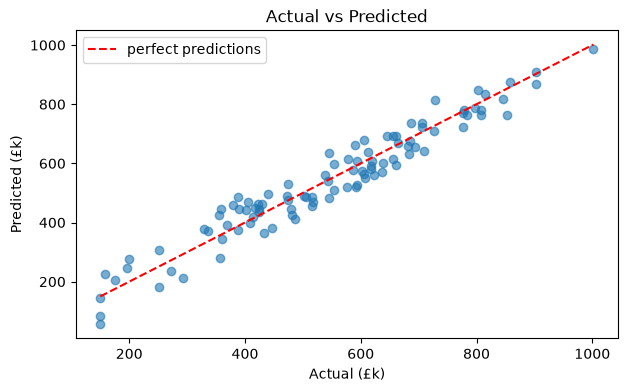

In [30]:
plt.scatter(y_test, y_pred, alpha=0.6)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", label="perfect predictions")
plt.xlabel("Actual (£k)"); plt.ylabel("Predicted (£k)"); plt.title("Actual vs Predicted"); plt.legend(); plt.show()

## 6 · Generalization & overfitting ▶️✏️
We fit curves of increasing complexity (polynomial degree) to a **small** sample of 30 homes and watch train vs test error.

In [32]:
small = df.sample(30, random_state=1)
Xa = small[["area"]] / 1000          # area in 1000s of sq ft keeps the polynomial numbers well-behaved
ya = small["price"]
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(Xa, ya, test_size=0.4, random_state=0)

rows = []
for degree in [1, 2, 3, 5, 8, 12]:
    poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    poly_model.fit(Xa_tr, ya_tr)
    rows.append({
        "degree": degree,
        "train_RMSE": np.sqrt(mean_squared_error(ya_tr, poly_model.predict(Xa_tr))),
        "test_RMSE":  np.sqrt(mean_squared_error(ya_te, poly_model.predict(Xa_te))),
    })
complexity = pd.DataFrame(rows)
complexity

,degree,train_RMSE,test_RMSE
0,1,123.800,99.013
1,2,123.230,101.169
2,3,112.725,124.228
3,5,93.408,175.231
4,8,93.317,174.996
5,12,93.154,177.539


### ✏️ Exercise 5
Store in `best_degree` the degree with the **lowest test RMSE** from the `complexity` table.

In [33]:
# ✏️ YOUR TURN — replace the ... / None parts
best_degree = 1
print(best_degree)

1


✅ Exercise 5


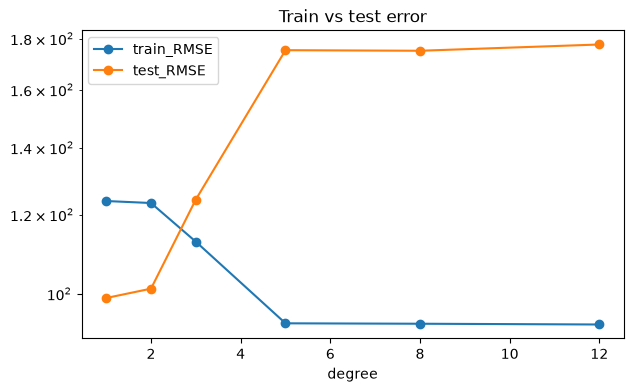

In [34]:
# ✔️ CHECK
check("Exercise 5", lambda: best_degree == int(complexity.loc[complexity["test_RMSE"].idxmin(), "degree"]),
      "complexity.loc[complexity['test_RMSE'].idxmin(), 'degree']")
complexity.plot(x="degree", y=["train_RMSE", "test_RMSE"], marker="o", logy=True, title="Train vs test error")
plt.show()

> 💬 Train error keeps falling as the degree grows — but what happens to test error? In this data the true price–area relationship is almost a straight line, so degree 1 already generalizes best and every extra wiggle only **overfits**. Try `df.sample(30, random_state=...)` with other seeds: does the best degree change?

## 7 · Ridge & Lasso ▶️

In [35]:
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=2.0).fit(X_train, y_train)

pd.DataFrame({"Linear": lr_model.coef_, "Ridge": ridge.coef_, "Lasso": lasso.coef_}, index=features).round(3)

,Linear,Ridge,Lasso
area,0.467,0.467,0.478
bedrooms,21.856,21.754,18.069
age,-0.754,-0.754,-0.748
distance,-17.658,-17.657,-17.623
random_noise,-1.435,-1.429,-0.000


Lasso sets `random_noise` to **exactly 0** — the feature-selection effect.

### ✏️ Exercise 6 — when does Lasso drop `bedrooms`?
Loop over `alphas = [0.1, 1, 2, 5, 10, 25, 50]`. For each, fit `Lasso(alpha=a)` on the training data and find the **first** alpha
where the coefficient for `bedrooms` becomes exactly 0. Store it in `alpha_drops_bedrooms`.

In [107]:
# ✏️ YOUR TURN — replace the ... / None parts
alphas = [0.1, 1, 2, 5, 10, 25, 50]
alpha_drops_bedrooms = None

for a in alphas:
    model = Lasso(alpha=a).fit(X_train, y_train)
    print(Lasso(alpha=a).fit(X_train, y_train).coef_[features.index("bedrooms")] )
    # if it's zero and we haven't found one yet, store a
    if Lasso(alpha=a).fit(X_train, y_train).coef_[features.index("bedrooms")] == 0:
        alpha_drops_bedrooms = a
        break
    else:
        continue

print(alpha_drops_bedrooms)


21.663597790382696
19.94400983032371
18.06909744890021
12.502565234739116
3.2254827596959115
0.0
25


In [61]:
# ✔️ CHECK
_expected = next(a for a in [0.1, 1, 2, 5, 10, 25, 50]
                 if Lasso(alpha=a).fit(X_train, y_train).coef_[features.index("bedrooms")] == 0)
check("Exercise 6", lambda: alpha_drops_bedrooms == _expected,
      "model.coef_[features.index('bedrooms')] == 0 → store the first such alpha")

✅ Exercise 6


## 8 · Compare the models ▶️

In [ ]:
def evaluate(name, model, Xtr=X_train, Xte=X_test):
    model.fit(Xtr, y_train)
    p = model.predict(Xte)
    return {"Model": name,
            "Train R2": model.score(Xtr, y_train),
            "MAE": mean_absolute_error(y_test, p),
            "RMSE": np.sqrt(mean_squared_error(y_test, p)),
            "R2": r2_score(y_test, p)}

results = pd.DataFrame([
    evaluate("Simple LR (area)", LinearRegression(), X_train[["area"]], X_test[["area"]]),
    evaluate("Multiple LR", LinearRegression()),
    evaluate("Ridge (alpha=1)", Ridge(alpha=1.0)),
    evaluate("Lasso (alpha=2)", Lasso(alpha=2.0)),
]).set_index("Model").round(3)
results


,Train R2,MAE,RMSE,R2
Model,,,,
Simple LR (area),0.668,87.542,105.717,0.688
Multiple LR,0.949,41.793,48.664,0.934
Ridge (alpha=1),0.949,41.803,48.672,0.934
Lasso (alpha=2),0.949,42.151,49.065,0.933


> 💬 Did regularization improve the test score here? Why not? (*Hint: compare Train R² and test R² — is the plain model overfitting?*)

---
# 🏆 Challenges
These are more open. Each has a ✔️ check where an exact answer exists.

### 🏆 Challenge 1 — Spot the data leak
A colleague adds a feature `price_per_sqft = price / area` and celebrates a big jump in R² (from 0.93 to about 0.97).
1. Add the column to a **copy** of `df`, include it in the features, fit a `LinearRegression`, and print the test R².
2. In a markdown cell, explain why this model is useless in real life.

In [ ]:
# ✏️ YOUR TURN — replace the ... / None parts
df_leak = df.copy()
df_leak["price_per_sqft"] = df_leak["price"]/df_leak["area"]
leak_features = features + ["price_per_sqft"]
# split with the same random_state=42, fit, and store the test R² in leak_r2
X = df_leak[leak_features]
#print(X.head())
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fit and predict
lr_model = LinearRegression().fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

# Error
leak_r2 = lr_model.score(X_train, y_train)
print("Train R2", leak_r2)
print("MAE ", mean_absolute_error(y_test, y_pred))
print("RMSE ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 ", r2_score(y_test, y_pred))

# Huge problem in that the target is actually in the features

Train R2 0.9734714163275157
MAE  27.17574609496938
RMSE  33.95748025733471
R2  0.9677761432192573


In [135]:
# ✔️ CHECK
check("Challenge 1", lambda: leak_r2 > results.loc["Multiple LR", "R2"], "price_per_sqft = price / area — then fit as usual")

✅ Challenge 1


### 🏆 Challenge 2 — Scale first, then regularize
Regularization penalises all coefficients equally, so feature **scale** matters. Build
`make_pipeline(StandardScaler(), Lasso(alpha=a))` for `a in [1, 5, 10, 20, 40, 80]` and record, for each alpha,
the list of features whose coefficient is 0. Store the results in a dict `dropped` (`alpha → list of feature names`).

Compare with Exercise 6: does Lasso now drop features in a different order?

In [ ]:
# ✏️ YOUR TURN — replace the ... / None parts
dropped = {}
for a in [1, 5, 10, 20, 40, 80]:
    pipe = make_pipeline(StandardScaler(), Lasso(alpha=a))
    pipe.fit(X_train, y_train)
    coefs = pipe[-1].coef_         # the Lasso step inside the pipeline
    #dropped[a] = [i for i, x in enumerate(coefs) if x == 0]
    dropped[a] = [i for i, x in zip(features, coefs) if x == 0]
dropped

1 [ 1.52738550e+02  1.26171666e+01 -1.16786190e+01 -4.99818656e+01
 -5.57901298e-02  5.76289215e+01]
5 [150.16385016  10.43450245  -7.67258963 -47.29510306  -0.
  56.06808724]
10 [146.93569905   7.71058443  -2.66502338 -43.93532894  -0.
  54.11464983]
20 [138.43783055   3.74538168  -0.         -41.8312223   -0.
  44.86045809]
40 [117.54712349   0.          -0.         -41.44311451  -0.
  21.78000966]
80 [ 75.16413265   0.          -0.         -20.8865732   -0.
   0.        ]


{1: [],
 5: ['random_noise'],
 10: ['random_noise'],
 20: ['age', 'random_noise'],
 40: ['bedrooms', 'age', 'random_noise'],
 80: ['bedrooms', 'age', 'random_noise']}

In [142]:
# ✔️ CHECK
check("Challenge 2", lambda: isinstance(dropped, dict) and len(dropped) == 6 and "random_noise" in dropped[80],
      "dropped[a] = [f for f, c in zip(features, coefs) if c == 0]")

✅ Challenge 2


### 🏆 Challenge 3 — Gradient descent for *multiple* features (vectorised)
Extend Exercise 3 to all 5 features. Use the **scaled** training data and vector maths:
`pred = X @ w + b`, `dw = (2/n) * X.T @ error`, `db = (2/n) * error.sum()`.
Run 2,000 steps with `lr = 0.05`. Your `w` should match `LinearRegression` trained on the same scaled data.

In [ ]:
x = np.array([4, 6, 8])
y_small = np.array([3, 4, 5])
alpha = 0.01

def run_gd(lr, steps=100):
    m, c = 0.0, 0.0
    n_pts = len(x)
    for _ in range(steps):
        error = (m * x + c) - y_small
        dm = (2 / n_pts) * (error * x).sum()
        dc = (2 / n_pts) * error.sum()
        m = m - (alpha * dm)      # step downhill for m
        c = c - (alpha * dc)     # step downhill for c
    return ((m * x + c - y_small) ** 2).mean(), m, c

print(run_gd(0.01))

In [159]:
# ✏️ YOUR TURN — replace the ... / None parts
# recall X_train is df of shape 400, 5
scaler = StandardScaler().fit(X_train) 
Xtr_s = scaler.transform(X_train) # scale all features with standard scaler and convert to numpy array
yt = y_train.to_numpy()

w = np.zeros(Xtr_s.shape[1])      # weights , start with array of zeros
b = 0.0; lr = 0.05
y = Xtr_s 

for _ in range(2000):
    error =  (Xtr_s @ w + b) - yt
    dw = (2/n) * (Xtr_s.T @ error)
    db = (2/n) * error.sum()
    print(db)
    w = w - (lr * dw)
    b = b - (lr * db)

reference = LinearRegression().fit(Xtr_s, yt)
print(np.round(w, 3)); print(np.round(reference.coef_, 3))

-848.448
-780.5721599999999
-718.1263872000001
-660.676276224
-607.82217412608
-559.1964001959936
-514.4606881803142
-473.30383312588896
-435.4395264758179
-400.60436435775244
-368.5560152091322
-339.07153399240167
-311.9458112730095
-286.99014637116875
-264.03093466147527
-242.90845988855725
-223.47578309747266
-205.59772044967482
-189.14990281370078
-174.0179105886048
-160.09647774151642
-147.2887595221951
-135.50565876041952
-124.665206059586
-114.6919895748191
-105.51663040883356
-97.0752999761269
-89.30927597803672
-82.16453389979375
-75.59137118781024
-69.54406149278545
-63.98053657336264
-58.86209364749363
-54.15312615569416
-49.820876063238636
-45.83520597817957
-42.168389499925226
-38.794918339931215
-35.6913248727367
-32.83601888291775
-30.209137372284356
-27.792406382501635
-25.569013871901433
-23.523492762149242
-21.64161334117732
-19.910284273883075
-18.317461531972434
-16.852064609414686
-15.503899440661433
-14.263587485408491
-13.122500486575762
-12.07270044764961
-11.10

In [160]:
# ✔️ CHECK
check("Challenge 3", lambda: np.allclose(w, reference.coef_, atol=0.05) and abs(b - reference.intercept_) < 0.05,
      "error = Xtr_s @ w + b - yt ; w = w - lr * dw ; b = b - lr * db")

✅ Challenge 3


---
# 📝 Assignment — Diabetes progression (built into scikit-learn)
`load_diabetes()` has 442 patients, 10 numeric features (already scaled) and a target measuring disease progression one year later.
No internet needed.

**Tasks** (create as many cells as you need):
1. Load the data into a DataFrame (`as_frame=True`) and show `.head()` and `.describe()`.
2. Plot the correlation heatmap. Which 3 features correlate most strongly (positively or negatively) with the target?
3. Split 80/20 with `random_state=42`.
4. Train **Simple LR** on the single best feature, then **Multiple LR** on all features. Report MAE, RMSE, R².
5. Train **Ridge** and **Lasso** for alphas `[0.01, 0.1, 1, 10]`. Which features does Lasso drop as alpha grows?
6. Build a comparison table of all models (train R² and test MAE/RMSE/R²).
7. Write **5 bullet points** for a non-technical audience: which model would you recommend and why? Is anything overfitting?

> 💡 Re-use the `evaluate()` pattern from Section 8.

In [70]:
# ✏️ YOUR TURN — replace the ... / None parts
from sklearn.datasets import load_diabetes
data = load_diabetes(as_frame=True)
diab = data.frame          # 10 features + "target"
diab.head()
# ... continue the tasks in new cells below

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038,0.051,0.062,0.022,-0.044,-0.035,-0.043,-0.003,0.020,-0.018,151.0
1,-0.002,-0.045,-0.051,-0.026,-0.008,-0.019,0.074,-0.039,-0.068,-0.092,75.0
2,0.085,0.051,0.044,-0.006,-0.046,-0.034,-0.032,-0.003,0.003,-0.026,141.0
3,-0.089,-0.045,-0.012,-0.037,0.012,0.025,-0.036,0.034,0.023,-0.009,206.0
4,0.005,-0.045,-0.036,0.022,0.004,0.016,0.008,-0.003,-0.032,-0.047,135.0


In [65]:
diab.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420e+02,4.420e+02,4.420e+02,4.420e+02,4.420e+02,4.420e+02,4.420e+02,4.420e+02,4.420e+02,4.420e+02,442.000
mean,-2.512e-19,1.231e-17,-2.246e-16,-4.798e-17,-1.381e-17,3.918e-17,-5.777e-18,-9.043e-18,9.269e-17,1.130e-17,152.133
std,4.762e-02,4.762e-02,4.762e-02,4.762e-02,4.762e-02,4.762e-02,4.762e-02,4.762e-02,4.762e-02,4.762e-02,77.093
min,-1.072e-01,-4.464e-02,-9.028e-02,-1.124e-01,-1.268e-01,-1.156e-01,-1.023e-01,-7.639e-02,-1.261e-01,-1.378e-01,25.000
25%,-3.730e-02,-4.464e-02,-3.423e-02,-3.666e-02,-3.425e-02,-3.036e-02,-3.512e-02,-3.949e-02,-3.325e-02,-3.318e-02,87.000
50%,5.383e-03,-4.464e-02,-7.284e-03,-5.670e-03,-4.321e-03,-3.819e-03,-6.584e-03,-2.592e-03,-1.947e-03,-1.078e-03,140.500
75%,3.808e-02,5.068e-02,3.125e-02,3.564e-02,2.836e-02,2.984e-02,2.931e-02,3.431e-02,3.243e-02,2.792e-02,211.500
max,1.107e-01,5.068e-02,1.706e-01,1.320e-01,1.539e-01,1.988e-01,1.812e-01,1.852e-01,1.336e-01,1.356e-01,346.000


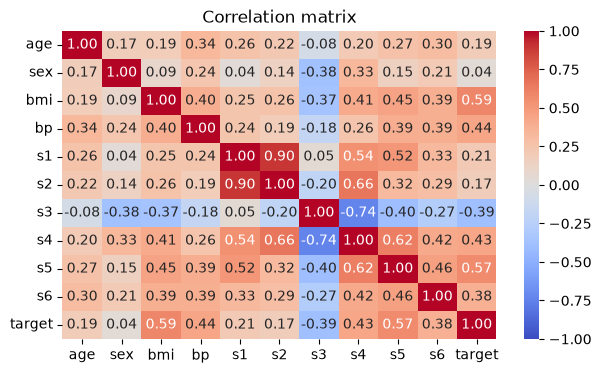

target    1.000
bmi       0.586
s5        0.566
bp        0.441
s4        0.430
s6        0.382
s1        0.212
age       0.188
s2        0.174
sex       0.043
s3       -0.395
Name: target, dtype: float64

In [ ]:
corr = diab.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()

corr["target"].sort_values(ascending=False)

# Top 3 correlating features
# BMI, S5, bp

slope (coef_)      = 998.578
intercept_         = 152.0


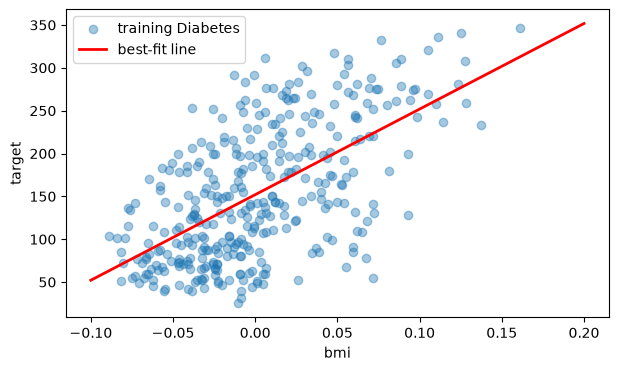

In [91]:
X_simple = diab[["bmi"]]          # double brackets → a 2-D table
y = diab["target"]
Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

simple = LinearRegression()
simple.fit(Xs_train, ys_train)

print(f"slope (coef_)      = {simple.coef_[0]:.3f}")
print(f"intercept_         = {simple.intercept_:.1f}")

plt.scatter(Xs_train, ys_train, alpha=0.4, label="training Diabetes")
xx = np.linspace(-0.1, 0.2, 25).reshape(-1, 1)
plt.plot(xx, simple.predict(pd.DataFrame(xx, columns=["bmi"])), "r", lw=2, label="best-fit line")
plt.xlabel("bmi"); plt.ylabel("target"); plt.legend(); plt.show()

In [ ]:
def mv_regression(model, alphas=(0.01, 0.1, 1, 10)):
    rows = []
    for a in alphas:
        rows.append(evaluate(f"{model.__name__} (alpha={a})", model(alpha=a)))
    return rows

def evaluate(name, model, Xtr=Xs_train, Xte=Xs_test):
    model.fit(Xtr, ys_train)
    p = model.predict(Xte)
    return {"Model": name,
            "Train R2": model.score(Xtr, ys_train),
            "MAE": mean_absolute_error(ys_test, p),
            "RMSE": np.sqrt(mean_squared_error(ys_test, p)),
            "R2": r2_score(ys_test, p)}

results = pd.DataFrame([
    evaluate("Simple LR (area)", LinearRegression(), Xs_train[["bmi"]], Xs_test[["bmi"]]),
    evaluate("Multiple LR", LinearRegression()),
    *mv_regression(Ridge),
    *mv_regression(Lasso),
]).set_index("Model").round(3)
results


,Train R2,MAE,RMSE,R2
Model,,,,
Simple LR (area),0.366,52.260,63.732,0.233
Multiple LR,0.366,52.260,63.732,0.233
Ridge (alpha=0.01),0.366,52.260,63.627,0.236
Ridge (alpha=0.1),0.361,52.264,62.990,0.251
Ridge (alpha=1),0.251,55.957,64.782,0.208
Ridge (alpha=10),0.051,62.627,71.443,0.037
Lasso (alpha=0.01),0.366,52.260,63.694,0.234
Lasso (alpha=0.1),0.365,52.261,63.380,0.242
Lasso (alpha=1),0.292,54.284,63.646,0.235


## Bullet points
* The results are all similar with the exception of Lasso/alpha=10 
* If I had to choose from these choices I would recommend Ridge/alpha=0.1 as it has the lowest RMSE and highest Test_R2=0.251
* Lasso/alpha=10 severly underfits with Test_R2=-0.012 - not sure that even makes sense
* From the results it doesn't look as if any model is overfitting given the Train_R2's and Test_R2's are not vastly different

In [ ]:
from sklearn.datasets import load_diabetes
diabetes_X, diabetes_y = load_diabetes(return_X_y=True)

<class 'numpy.ndarray'>


### ✍️ Your 5-bullet recommendation
*(double-click to edit)*
- …
- …
- …
- …
- …

---
### ✅ You've finished ML Module 1 hands-on!
You explored correlation, trained simple and multiple linear regression, wrote gradient descent and the evaluation metrics yourself, saw overfitting happen, and used Ridge & Lasso to control complexity.